In [1]:
import warnings

warnings.simplefilter("ignore")
#from altaipony.lcio import from_mast
#from funcs.detrend import custom_detrending, estimate_detrended_noise
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

search_result = search_lightcurve("AU Mic") 
lc2min = search_result[7].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
lc2_m = lc2.normalize().remove_nans()

x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)



In [2]:
vetores = [
    [2036.7054, 2036.71023],
    [2037.4429, 2037.44941],
    [2041.195,2041.387],
    [2037.663,2037.787],
    [2037.6736, 2037.6953],
    [2037.71922, 2037.7435],
    [2039.18134, 2039.1888],
    [2039.26492, 2039.26775],
    [2039.34872, 2039.35791],
    [2039.82051, 2039.84413],
    [2042.48425, 2042.49485],
    [2042.50061, 2042.51093],
    [2047.21325, 2047.2352],
    [2047.34522, 2047.35652],
    [2047.6273,2047.6467],
    [2049.6324,2049.8531],
    [2051.1540,2051.2290],
    [2051.4325,2051.5796],
    [2054.2655,2054.3711],
    [2055.8981,2055.9470],
    [2056.8229,2056.8623],
    [2047.50326, 2047.51074],
    [2047.62795, 2047.63086],
    [2047.83154, 2047.83609],
    [2047.84043, 2047.84221],
    [2049.73685, 2049.7421],
    [2050.78104, 2050.78403],
    [2050.85602, 2050.8691],
    [2050.31549, 2050.31673],
    [2051.44131, 2051.45145],
    [2053.08171, 2053.08283],
    [2053.4107, 2053.6154],
    [2042.4797,2042.5663],
    [2055.90268, 2055.90634],
    [2056.26941, 2056.27345],
    [2056.68717, 2056.70876],
    [2056.82836, 2056.83581],
    [2056.90861, 2056.92518],
    [2057.7945, 2057.9036],
    [2058.24052, 2058.24389],
    [2058.1191,2058.2976],
    [2058.83466, 2058.9741],
    [2059.10883, 2059.11091],
    [2058.803,2058.912],
    [2056.9016,2057.1076],
    [2059.54703, 2059.56109]
]

vetor_true = [False]*len(x2min)

for j in range(len(x2min)):
    for i in range(len(vetores)):
        if (x2min[j]>=vetores[i][0]) and (x2min[j]<=vetores[i][1]):
            vetor_true[j] = True

mascara = np.array(vetor_true)



In [3]:
valores = [
    [2036.7051, 2036.71029],
    [2037.44301, 2037.45116],
    [2037.67311, 2037.73284],
    [2039.1808, 2039.19745],
    [2039.26492, 2039.26847],
    [2039.34872, 2039.36633],
    [2039.80907, 2039.8322],
    [2040.0282, 2040.0972],
    [2041.1855, 2041.3798],
    [2042.48388, 2042.5350],
    [2047.21322, 2047.2433],
    [2047.34522, 2047.36154],
    [2047.5036, 2047.51074],
    [2047.62795, 2047.6467],
    [2047.83154, 2047.83627],
    [2047.84043, 2047.84221],
    [2049.73685, 2049.74298],
    [2049.6730, 2049.8201],
    [2050.78041, 2050.7841],
    [2050.8560, 2050.8799],
    [2050.31549, 2050.31673],
    [2051.1625,2051.2091],
    [2051.44076, 2051.5667],
    [2053.08171, 2053.08283],
    [2053.42735, 2053.5686],
    [2054.2776,2054.3618],
    [2055.90134, 2055.9496],
    [2056.26941, 2056.27359],
    [2056.82718, 2056.8597],
    [2056.90861, 2057.1060],
    [2057.7987, 2057.8672],
    [2058.1318, 2058.2471],
    [2058.24047, 2058.24378],
    [2058.83466, 2058.8589],
    [2059.54703, 2059.5660],
]


valores_true = [False]*len(x2min)
for j in range(len(x2min)):
    for i in range(len(valores)):
        if (x2min[j]>=valores[i][0]) and (x2min[j]<=valores[i][1]):
            valores_true[j] = True

mascara_1 = np.array(valores_true)

In [4]:
flcd = lc2_m.flatten(window_length=320, polyorder=4, return_trend=False, break_tolerance=100, niters=3, sigma=2.5, mask=mascara)
tempo_detrend = np.ascontiguousarray(flcd.time.value, dtype=np.float64) 
fluxo_detrend = np.ascontiguousarray(flcd.flux, dtype=np.float64)


In [5]:
#Criando um novo valor de x_detrend e y_detrend agora sem considerar os trânsitos e as grandes explosões
x_detrend = []
y_detrend = []
for j in range(len(mascara_1)):
    if mascara_1[j] == False:
        y_detrend.append(fluxo_detrend[j])
        x_detrend.append(tempo_detrend[j])

x_detrend = np.array(x_detrend)
y_detrend = np.array(y_detrend)

y_mean = np.mean(y_detrend)
#Media para todos os pontos do eixo x, para apresentar no grafico 
#y_mean2 = [y_mean for i in range(len(y))]
y_mean2 = [y_mean]*len(y_detrend)
#Calculo do desvio padrao dos dados
desvio = (np.std(y_detrend))
#print(y_mean)
#Media mais desvio padrao
med_desv = y_mean2+desvio

In [6]:
med_desv2 = y_mean + (2*desvio)
med_desv3 = y_mean - (2*desvio)
xdefinitivo = []
ydefinitivo = []
for j in range(len(y_detrend)):
    if y_detrend[j] < med_desv2 and y_detrend[j]>med_desv3:
        ydefinitivo.append(y_detrend[j])
        xdefinitivo.append(x_detrend[j])

xdefinitivo = np.array(xdefinitivo)
ydefinitivo = np.array(ydefinitivo)

#Calculo novo da média e do desvio padrão do ruido 
y_m = np.mean(ydefinitivo)
y_m2 = [y_m]*len(ydefinitivo)
desvio2 = (np.std(ydefinitivo))
#med = desvio2
med = y_m2 + desvio2

<IPython.core.display.Javascript object>


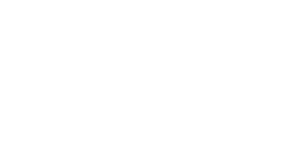

In [7]:
%matplotlib notebook
plt.rcParams['font.size'] = 16
fig,ax = plt.subplots(1,1,figsize=(10,5))
#Plot do detrend
data_line = ax.plot(tempo_detrend,fluxo_detrend, label='Dados', marker='.', color='black')
data_line2 = ax.plot(xdefinitivo,y_m2, label='média',linestyle='--', color='blue')
#Plot da linha pontilhada media e desvio
mean_line = ax.plot(xdefinitivo,med, label='Média+$\sigma$', linestyle='--', color = 'red')
#mean_line2 = ax.plot(xdefinitivo,desd, label='$\sigma$', linestyle='--', color = 'blue')

#Legenda
legend = ax.legend(loc='upper right')
ax.set_title("Detrend Setor 27 (20 segundos)")
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()
plt.show()


In [8]:
# Valores de início e término da flare (substitua pelos valores desejados)
start_input = 2037.44290




stop_input = 2037.45116




def ener_flare(start, stop, tempo_detrend, fluxo_detrend):
    flux_flare = []
    tempo_flare = []
    for i in range(len(tempo_detrend)):
        if tempo_detrend[i] >= start and tempo_detrend[i] <= stop:
            flux_flare.append(fluxo_detrend[i])
            tempo_flare.append(tempo_detrend[i])

    flux_flare = np.array(flux_flare)
    tempo_flare = np.array(tempo_flare)
    
    return flux_flare, tempo_flare
print()
# Chamada da função ener_flare com os dados de exemplo
#fig,ax = plt.subplots(1,1,figsize=(10,5))
flux_flare, tempo_flare = ener_flare(start_input, stop_input, tempo_detrend, fluxo_detrend)
# Criação do gráfico do tempo_flare em relação ao fluxo_flare
#fig,ax = plt.subplots(1,1,figsize=(10,5))
plt.plot(tempo_flare, flux_flare, 'r')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

In [9]:
##### Alguns dados básicos##################
fl129=pd.read_csv('flares_setor27.csv') #lendo os flares 
tess_f = pd.read_csv('tess_functionx1.csv') #lendo os arquivos da função de resposta
tf = pd.DataFrame(tess_f)
df = pd.DataFrame(fl129)

nm= np.array(tf["nm"]) # comprimento de onda em nm
ry= np.array(tf["ry"]) # tess function response

In [10]:
#Energia da flare
from PyAstronomy.pyasl import planck

#Mudança nm para cm e metro 
nm_metros = nm*(1e-9) #de nm para metros 
nm_cm = nm*(1e-7) #de nm para cm 

#Constantes importantes 
Teff= 3700# temperatura efetiva au mic
Tflare=10000# temperatura flare
raio=0.75*6.957e+10 # raio solar cm
sb1=5.67051e-5 #ergs cm-2*s-1*K-4

###########################
#Calculo da função de Planck
# Essa função (Bs=planck(Teff,lam=nm_metros)) da em [W/(m**2 m)] então
Bs=planck(Teff,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)
Bf=planck(Tflare,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)
##### Alguns dados básicos##################



4.74664204141517e+32


<IPython.core.display.Javascript object>


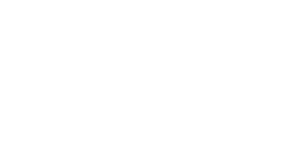

In [11]:
#%matplotlib notebook
flux_flare1 = np.array(flux_flare)
tempo_flare1 = np.array(tempo_flare) 

# Fluxo relativo da estrela (valor mínimo de fluxo na região da flare)
f_rel_estrela = np.min(flux_flare1)

# Calcular a amplitude da flare (diferença entre o fluxo máximo da flare e o fluxo relativo da estrela)
amplitude_flare =  flux_flare1 - f_rel_estrela


# Integral
Aflare = amplitude_flare*np.pi*(raio**2) #(cm^2)

Aflare1 = simps(ry*Bs,nm_cm)/simps(ry*Bf,nm_cm)

# Área total da flare
Atotal = Aflare*Aflare1 #cm^2

# Luminosidade da flare
L = sb1*(Tflare**4)*Atotal #erg/s

# Energia bolométrica do flare

E1 = simps(L,tempo_flare1*86400) #erg



print(E1)

# Criação do gráfico do tempo_flare em relação ao fluxo_flare
fig,ax = plt.subplots(1,1,figsize=(10,5))
plt.plot(tempo_flare1, amplitude_flare, 'r')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

In [12]:
flcd.to_fits(path='lightcurve_s27.fits', overwrite=True)
#Transformando os arquivos em fits e salvando 
from astropy.io import fits
hdu = fits.open('lightcurve_s27.fits')
type(hdu)

astropy.io.fits.hdu.hdulist.HDUList

In [13]:
from astropy.table import Table
dat = Table.read('lightcurve_s27.fits', format='fits')
df = dat.to_pandas()

In [14]:
print(df.isna().sum()) #Contagem de dados nans nas colunas
df = df.dropna(subset=['TIME']) 
df = df.dropna(subset=['QUALITY']) # retirar valores 
print(df.isna().sum())
df.drop(df[df.QUALITY>0].index ,inplace=True) # exclui linhas onde flag com raios cósmicos

TIME          0
FLUX          0
FLUX_ERR      0
CADENCENO     0
MOM_CENTR1    0
MOM_CENTR2    0
QUALITY       0
dtype: int64
TIME          0
FLUX          0
FLUX_ERR      0
CADENCENO     0
MOM_CENTR1    0
MOM_CENTR2    0
QUALITY       0
dtype: int64


In [15]:
%matplotlib inline
time=df["TIME"] # tempo
flux=df["FLUX"] #flux
s=df["QUALITY"] # sap_quality
sf  = df['QUALITY'] > 1 # filtra flag com valores maiores que 1 ou seja flag 128 e 8192, são raios cósmicos
#from scipy.signal import savgol_filter
rf = np.mean(flux)/np.mean(flux) #Fluxo relativo

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


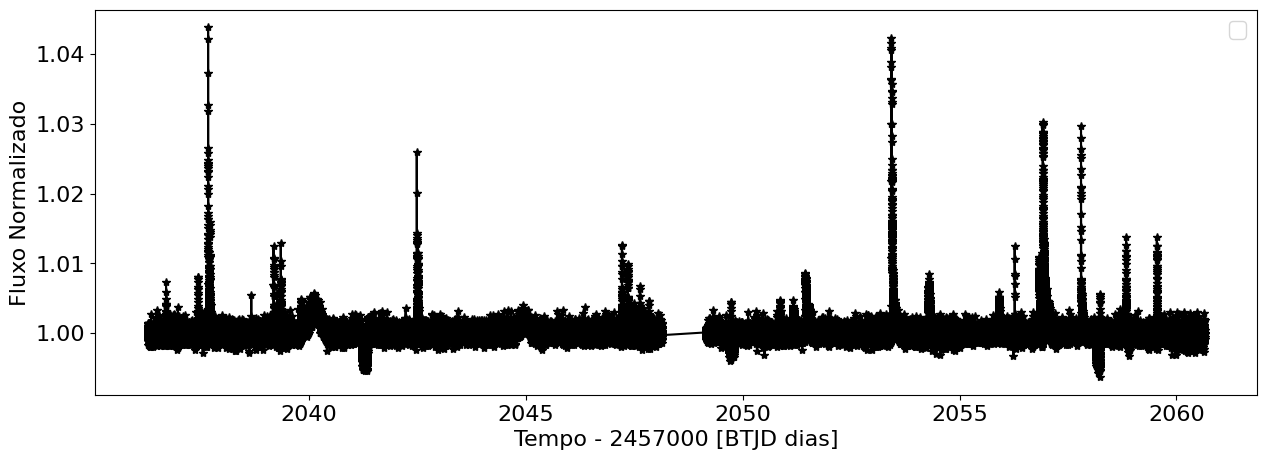

In [16]:
fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(time,flux, 'k*-')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()

In [17]:
def dur(start,stop):
    dur1=abs(stop[0]-start[0])*1440
    #print("%.5f",dur1)
    #return dur1
    print("%.5f" %dur1)
    #dur1=abs(stop[1]-start[1])
    #print("diferença:", "%.5f" %dur1, "min", "inicio:", "%.5f" %start[1],"fim:", "%.5f" %stop[1], "")
    #print("inicio:", "%.5f" %start,"fim:", "%.5f" %stop, "min")
    
#Tempo de subida e descida
def subdes(start,stop):
    maximo = start[1]
    maximo_t = 0.0
    for i in range(len(time)):
        if time[i]>start[0] and time[i]<stop[0]:
            if flux[i]> maximo:
                maximo = flux[i]
                maximo_t = time[i]
    rise=(maximo_t-start[0])*1440
    decay=(stop[0]-maximo_t)*1440
    #print("Subida:", "%.5f" %rise, "min", "Descida:", "%.5f" %decay, "min")
    #print("%.5f" %decay)
    print("%.5f" %rise)
    #print("maximo", maximo)
    #print("inicio, fim", start[0],stop[0])
    #print("duração", (stop[0]-start[0])*1440)
    #print("duração2", (rise+decay))
    

def ampl(start,stop):
    maximo = start[1]
    minimo = start[1]
    med = np.mean(flux)
    for i in range(len(time)):
        if time[i]>start[0] and time[i]<stop[0]:
            if flux[i]> maximo:
                maximo = flux[i]
            if flux[i] < minimo:
                minimo = flux[i]  
    amplitude = maximo-minimo 
    print( "%.8f" %amplitude)
